# AI-Powered Financial Fraud Detection Using XGBoost & SHAP

### End-to-End Machine Learning Project

**Objective:** Build an explainable machine-learning system that identifies potentially fraudulent financial transactions while addressing severe class imbalance.

**Workflow:** Data Understanding → Data Cleaning → EDA → Feature Engineering → Feature Preparation → Stratified Splitting → Class-Imbalance Handling → XGBoost → Threshold Optimization → Final Evaluation → SHAP Explainability → Risk Scoring → Model Saving

> **Target:** `isFraud` — `0` represents a legitimate transaction and `1` represents a fraudulent transaction.


## 1. Import Required Libraries
Import the packages used for data manipulation, visualization, model training, evaluation, explainability, and artifact persistence. Keeping imports together makes the notebook easier to reproduce and maintain.


In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

from xgboost import XGBClassifier

import shap
import joblib

## 2. Load the Transaction Dataset
Load `fraud.csv` into a Pandas DataFrame. All subsequent analysis and modelling are based on this transaction-level dataset.


In [209]:
df = pd.read_csv('fraud.csv')

## 3. Understand the Dataset
Before modelling, inspect sample records, dimensions, data types, missing values, descriptive statistics, and the target distribution. This establishes the data-quality baseline and reveals the degree of class imbalance.

### 3.1 Preview, Shape & Data Types


In [210]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [211]:
df.shape

(2304047, 11)

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304047 entries, 0 to 2304046
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 193.4+ MB


In [213]:
df.isnull().sum()

,0
step,0
type,0
amount,1
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [220]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,2.304046e+06,2.304046e+06,2.304046e+06,2.304046e+06,2.304046e+06,2.304046e+06,2.304046e+06,2304046.0
mean,9.790557e+01,1.610262e+05,8.535921e+05,8.751275e+05,9.991389e+05,1.114145e+06,9.261968e-04,0.0
std,6.740483e+01,2.687983e+05,2.926401e+06,2.962733e+06,2.307035e+06,2.396213e+06,3.041939e-02,0.0
min,1.000000e+00,6.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,2.600000e+01,1.316667e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,1.310000e+02,7.896108e+04,1.483250e+04,0.000000e+00,1.412915e+05,2.316468e+05,0.000000e+00,0.0
75%,1.600000e+02,2.163335e+05,1.185490e+05,1.606906e+05,9.521724e+05,1.150866e+06,0.000000e+00,0.0
max,1.880000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.228378e+07,4.265577e+07,1.000000e+00,0.0


### 3.2 Fraud Target Distribution
Inspect the number and percentage of legitimate and fraudulent transactions before modelling.


In [214]:
df["isFraud"].value_counts()

,count
isFraud,
0.0,2301912
1.0,2134


In [215]:
df["isFraud"].value_counts(normalize=True) * 100

,proportion
isFraud,
0.0,99.90738
1.0,0.09262


In [216]:
print(df["isFraud"].value_counts(dropna=False))
print("Missing values:", df["isFraud"].isna().sum())
print("Unique values:", df["isFraud"].unique())

isFraud
0.0    2301912
1.0       2134
NaN          1
Name: count, dtype: int64
Missing values: 1
Unique values: [ 0.  1. nan]


## 4. Data Cleaning & Target Validation
The target must contain known class labels before supervised learning. Transactions with a missing `isFraud` value are removed rather than assigning an artificial fraud label, and the remaining target values are converted to integers.


In [217]:
df = df.dropna(subset=["isFraud"]).copy()

df["isFraud"] = df["isFraud"].astype(int)

In [218]:
print(df["isFraud"].value_counts())
print(df["isFraud"].unique())
print(df["isFraud"].isna().sum())

isFraud
0    2301912
1       2134
Name: count, dtype: int64
[0 1]
0


## 5. Exploratory Data Analysis (EDA)
EDA is performed **before feature engineering and model training** so that modelling decisions are guided by patterns observed in the original cleaned data. We examine class imbalance and how fraud varies across transaction types.

### 5.1 Fraud Distribution by Transaction Type


In [219]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
      .agg(["count", "sum", "mean"])
      .sort_values("mean", ascending=False)
)

In [221]:
print(fraud_by_type)

           count   sum      mean
type                            
TRANSFER  190883  1059  0.005548
CASH_OUT  825550  1075  0.001302
CASH_IN   508638     0  0.000000
DEBIT      14983     0  0.000000
PAYMENT   763992     0  0.000000


### 5.2 Class Imbalance Visualization
Visualize the strong imbalance between legitimate and fraudulent transactions.


In [222]:
fraud_counts = df["isFraud"].value_counts()

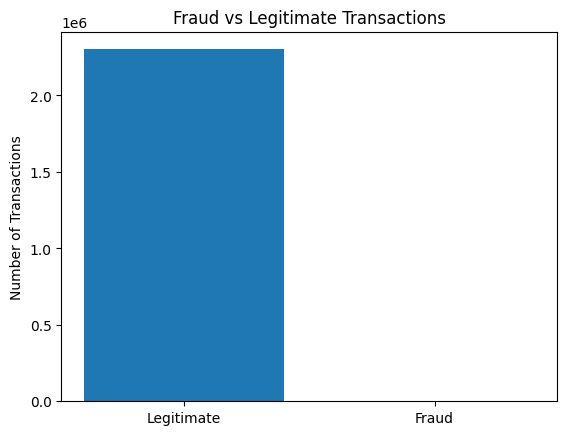

In [223]:
plt.bar(
    ["Legitimate", "Fraud"],
    [fraud_counts.get(0, 0), fraud_counts.get(1, 0)]
)
plt.title("Fraud vs Legitimate Transactions")
plt.ylabel("Number of Transactions")
plt.show()

## 6. Fraud-Oriented Feature Engineering
Create behavioural features that may expose suspicious balance movements and transaction patterns. These features preserve the original transaction context while giving XGBoost additional signals to learn from.

### Engineered Features
- **Origin balance error:** difference between expected and recorded sender balance.
- **Destination balance error:** difference between expected and recorded receiver balance.
- **Zero-balance indicators:** identify accounts with zero recorded balances.
- **Amount-to-origin-balance ratio:** measures transaction size relative to sender funds.
- **Transaction hour:** derives a simple time-of-day feature from `step`.


In [224]:
# Sender balance inconsistency
df["orig_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

# Receiver balance inconsistency
df["dest_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

### 6.1 Additional Behavioural Features


In [225]:
df["orig_zero_balance"] = (
    df["oldbalanceOrg"] == 0
).astype(int)

df["dest_zero_balance"] = (
    df["oldbalanceDest"] == 0
).astype(int)

df["amount_to_orig_balance"] = (
    df["amount"] /
    (df["oldbalanceOrg"] + 1)
)

df["hour"] = df["step"] % 24


## 7. Feature Selection & Categorical Encoding
Prepare the model-ready feature set. High-cardinality account identifiers are excluded from this baseline model, and `isFlaggedFraud` is removed so the model learns transaction patterns rather than relying on an existing rule-based fraud flag. The transaction `type` is then one-hot encoded.


In [226]:
df = df.drop(
    columns=[
        "nameOrig",
        "nameDest"
    ]
)

In [227]:
df = df.drop(columns=["isFlaggedFraud"])

### 7.1 One-Hot Encode Transaction Type


In [228]:
df = pd.get_dummies(
    df,
    columns=["type"],
    drop_first=False
)

## 8. Define Predictor Matrix and Target
Separate the prepared dataset into predictor variables (`X`) and the fraud target (`y`).


In [229]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

## 9. Stratified Train / Validation / Test Split
Use stratified splitting because fraud is rare. The three subsets have distinct purposes:

- **Training set:** fits the XGBoost model.
- **Validation set:** selects the classification threshold.
- **Test set:** remains untouched until final evaluation.

This prevents the final test set from influencing model or threshold selection.


In [230]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=42,
    stratify=y_train_val
)

### 9.1 Verify Split Sizes and Class Distribution
Confirm that the split produced the expected dataset sizes and preserved the rare fraud class.


In [231]:
X_train.shape

(1474588, 17)

In [232]:
X_test.shape

(460810, 17)

In [233]:
y_train.value_counts()

,count
isFraud,
0,1473222
1,1366


In [234]:
y_test.value_counts()

,count
isFraud,
0,460383
1,427


## 10. Handle Class Imbalance
Fraud is the minority class, so overall accuracy alone can be misleading. Calculate `scale_pos_weight` **only from the training data** and pass it to XGBoost so fraudulent observations receive greater importance during learning.


In [235]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("Scale Pos Weight:", scale_pos_weight)

Negative: 1473222
Positive: 1366
Scale Pos Weight: 1078.493411420205


## 11. Train the XGBoost Fraud Classifier
Train XGBoost using class weighting plus row and feature subsampling. XGBoost is well suited to structured/tabular data and can capture nonlinear relationships between transaction characteristics.


In [236]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

## 12. Optimize the Decision Threshold on Validation Data
A probability cutoff of `0.50` is not automatically optimal for an imbalanced fraud problem. Use validation-set probabilities to examine the precision–recall trade-off and select the threshold that maximizes F1-score.

**Important:** the test set is not used for threshold selection.


In [237]:
val_probability = model.predict_proba(X_val)[:, 1]

In [238]:
precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_probability
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Validation Precision:", precision[best_index])
print("Validation Recall:", recall[best_index])
print("Validation F1:", f1_scores[best_index])

Best Threshold: 0.9997335
Validation Precision: 1.0
Validation Recall: 0.9853372434017595
Validation F1: 0.9926144755777723


## 13. Final Model Evaluation on Unseen Test Data
Apply the validation-selected threshold to the untouched test set. Report multiple metrics because fraud detection should not be judged by accuracy alone.

- **Accuracy:** overall proportion of correct predictions.
- **Precision:** how many flagged transactions are actually fraudulent.
- **Recall:** how many actual fraud cases are detected.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** ranking performance across thresholds.
- **PR-AUC:** especially informative for an imbalanced positive class.


In [239]:
test_probability = model.predict_proba(X_test)[:, 1]

y_pred = (
    test_probability >= best_threshold
).astype(int)

### 13.1 Classification Report


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

### 13.2 Confusion Matrix


In [241]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[460383      0]
 [     6    421]]


### 13.3 ROC-AUC and PR-AUC


In [242]:
roc_auc = roc_auc_score(
    y_test,
    test_probability
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.4999445706393091


In [243]:
pr_auc = average_precision_score(
    y_test,
    test_probability
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.0009116463119996293


## 14. Global Feature Importance
Inspect XGBoost's built-in feature importance to identify which original and engineered variables contribute most strongly to the model's decisions.


In [244]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(15))

                   Feature  Importance
3           newbalanceOrig    0.353827
6       orig_balance_error    0.213195
15            type_PAYMENT    0.143421
8        orig_zero_balance    0.132940
10  amount_to_orig_balance    0.062052
14              type_DEBIT    0.042805
9        dest_zero_balance    0.009557
1                   amount    0.006885
7       dest_balance_error    0.006120
2            oldbalanceOrg    0.006114
4           oldbalanceDest    0.005402
16           type_TRANSFER    0.004439
5           newbalanceDest    0.003252
0                     step    0.003182
12            type_CASH_IN    0.003153


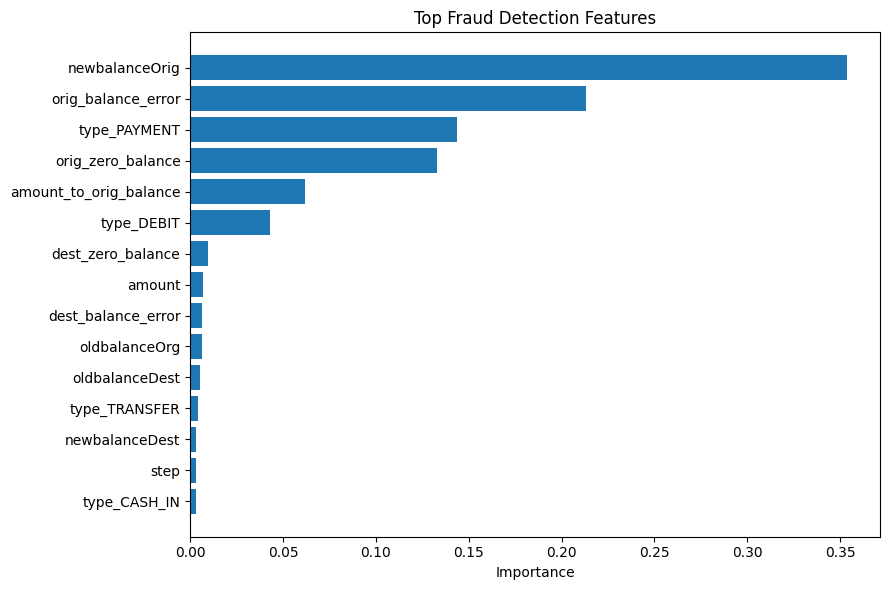

In [245]:
top_features = importance.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top Fraud Detection Features")
plt.tight_layout()
plt.show()

## 15. Explainable AI with SHAP
Use SHAP to move beyond a black-box fraud prediction. The summary plot explains model behaviour globally, while the waterfall plot shows how individual features push a single transaction toward or away from the fraud prediction.

### 15.1 Global SHAP Explanation


In [246]:
explainer = shap.TreeExplainer(model)

sample = X_test.sample(
    min(1000, len(X_test)),
    random_state=42
)

shap_values = explainer(sample)

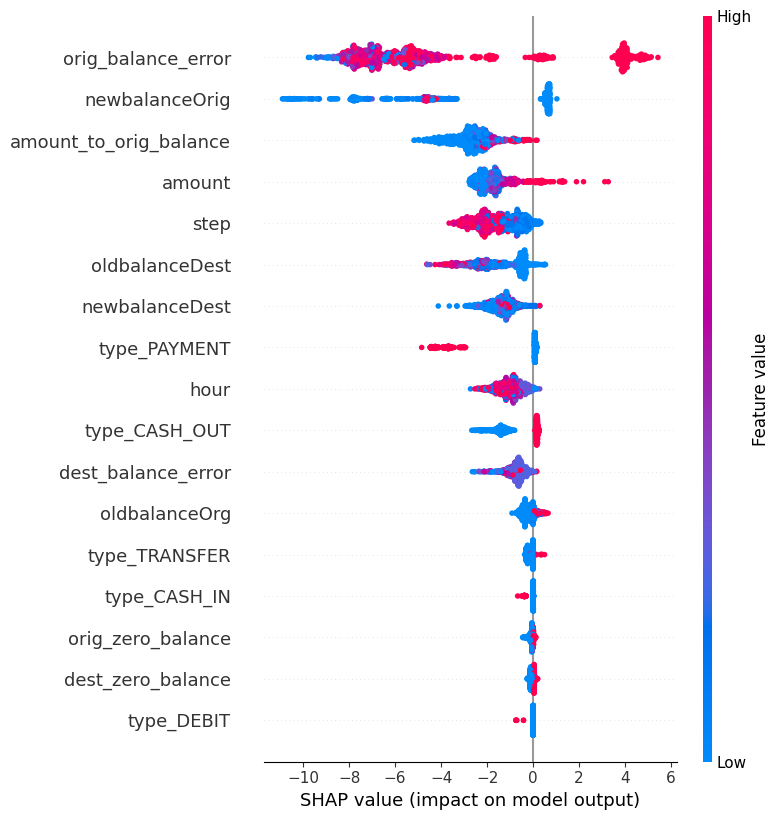

In [247]:
shap.summary_plot(
    shap_values,
    sample
)

### 15.2 Individual Transaction Explanation


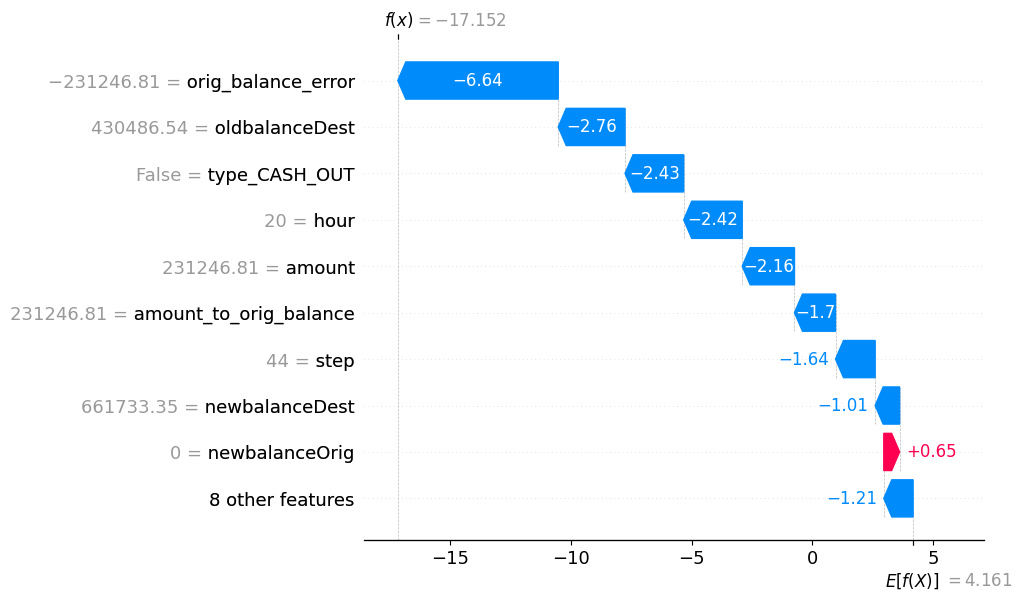

In [248]:
transaction = X_test.iloc[[0]]

transaction_shap = explainer(transaction)

shap.plots.waterfall(
    transaction_shap[0]
)

## 16. Application-Level Fraud Risk Scoring
Convert predicted fraud probabilities into simple project-defined risk bands for a future user interface. These categories are illustrative application rules—not universal banking or industry thresholds.


In [249]:
def get_risk_level(probability):
    if probability >= 0.80:
        return "CRITICAL"
    elif probability >= 0.60:
        return "HIGH"
    elif probability >= 0.30:
        return "MEDIUM"
    else:
        return "LOW"

In [250]:
prob = 0.87

print(get_risk_level(prob))

CRITICAL


## 17. Save the Trained Model & Supporting Artifacts
Save the XGBoost model using its native JSON format for more reliable loading across environments. Save the expected feature order and optimized threshold separately with Joblib for use in the Streamlit application.


In [ ]:
# Save XGBoost model in native JSON format
model.save_model("fraud_xgboost.json")

# Save the exact feature order expected by the application
joblib.dump(
    list(X_train.columns),
    "model_features.pkl"
)

# Save the optimized classification threshold
joblib.dump(
    best_threshold,
    "threshold.pkl"
)

print("Model saved: fraud_xgboost.json")
print("Features saved: model_features.pkl")
print("Threshold saved: threshold.pkl")


## 18. Project Conclusion
This notebook demonstrates a systematic end-to-end fraud-detection workflow: data-quality validation, exploratory analysis, fraud-oriented feature engineering, stratified data splitting, class-imbalance handling, XGBoost modelling, validation-based threshold optimization, multi-metric test evaluation, and SHAP explainability.

### Interview Summary
The project does not rely only on accuracy. Because fraud is a rare class, the model is evaluated with precision, recall, F1-score, ROC-AUC, and PR-AUC. The decision threshold is selected on validation data rather than the final test set, and SHAP is used to explain both global model behaviour and individual transaction predictions. The resulting model and supporting artifacts are saved for deployment in a Streamlit interface.
